# Electricity Consumption Pattern Analysis 

This notebook clusters households from the `Smart Meters in London` dataset by their electricity
consumption behaviour, validates the clusters, visualizes them, analyzes peak/off-peak usage per
cluster, and generates cluster-specific energy-saving recommendations.

Files used (place them in the same folder as this notebook, or edit `DATA_DIR` below):
- `daily_dataset.csv` — per household, per day: median/mean/max/min/std/sum/count of energy
- `informations_households.csv` — household ID, tariff type, Acorn demographic group
- `acorn_details.csv`, `uk_bank_holidays.csv`, `weather_daily_darksky.csv`, `weather_hourly_darksky.csv` — supporting/optional context

> Note: this dataset gives you daily-level statistics, not hour-of-day readings. That's enough
> for household-level clustering (Steps 1–10), but true hour-by-hour peak/off-peak detection
> (Step 11) needs the companion file `hhblock_dataset.csv` (48 half-hourly columns per household
> per day) from the same Kaggle dataset. This notebook includes both: an approximate
> weekday/weekend + seasonal peak analysis that works with what you have now, and a ready-to-use
> function for the true hourly version if you add `hhblock_dataset.csv` later.


## Step 1 — Environment Setup

Import the libraries used across the whole notebook: `pandas`/`numpy` for data handling,
`scikit-learn` for scaling, PCA, clustering and validation metrics, and `matplotlib`/`seaborn`
for plots. Nothing analytical happens in this cell — it just prepares the toolbox.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = r"D:\archive (1)"  # change this if your CSVs are in a different folder


## Step 2 — Load and Inspect the Data

Read the two files we actually need for clustering: `daily_dataset.csv` (the consumption records)
and `informations_households.csv` (household metadata). We immediately check shape, dtypes and
missing values — this tells us how much cleaning Step 3 needs to do, before we write any cleaning
code blind.

In [5]:
daily_df = pd.read_csv(f"{DATA_DIR}/daily_dataset.csv", parse_dates=["day"])
households_df = pd.read_csv(f"{DATA_DIR}/informations_households.csv")

print("daily_dataset shape:", daily_df.shape)
print("date range:", daily_df["day"].min(), "to", daily_df["day"].max())
print("unique households:", daily_df["LCLid"].nunique())
print()
print("Missing values per column:")
print(daily_df.isna().sum())
daily_df.head()


daily_dataset shape: (3510433, 9)
date range: 2011-11-23 00:00:00 to 2014-02-28 00:00:00
unique households: 5566

Missing values per column:
LCLid                0
day                  0
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11331
energy_sum          30
energy_min          30
dtype: int64


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066


## Step 3 — Data Cleaning

Three cleaning decisions, each explained:

1. Drop rows with missing `energy_mean`/`energy_max`/`energy_min`. These represent days where
   the meter reading gap was too large to summarize — there's no safe way to fill in a full day of
   missing consumption, so we drop rather than guess.
2. Keep only households with at least 200 recorded days. Households that joined or left the
   trial early would otherwise get an unreliable average that's really based on a handful of days —
   that would distort the clustering distances later.
3. Drop exact duplicate `(LCLid, day)` rows, if any exist, to avoid double-counting a day.

In [6]:
daily_df = daily_df.dropna(subset=["energy_mean", "energy_max", "energy_min"])

day_counts = daily_df.groupby("LCLid")["day"].count()
valid_ids = day_counts[day_counts >= 200].index
daily_df = daily_df[daily_df["LCLid"].isin(valid_ids)].copy()

daily_df = daily_df.drop_duplicates(subset=["LCLid", "day"])

print("After cleaning:", daily_df.shape)
print("Households remaining:", daily_df["LCLid"].nunique())


After cleaning: (3506292, 9)
Households remaining: 5530


## Step 4 — Merge Household Metadata

Join the Acorn demographic group onto the consumption data. We will **not** feed this into the
clustering algorithm — it's a label describing the household, not a consumption pattern. We keep
it aside so that after clustering (Step 10) we can check whether the data-driven clusters line up
with known demographic groups. That comparison is a strong point to make in your report/viva:
it shows your clusters aren't just noise.

In [7]:
daily_df = daily_df.merge(households_df[["LCLid", "Acorn_grouped"]], on="LCLid", how="left")
daily_df[["LCLid", "day", "energy_mean", "Acorn_grouped"]].head()


,LCLid,day,energy_mean,Acorn_grouped
0,MAC000131,2011-12-15,0.432045,Affluent
1,MAC000131,2011-12-16,0.296167,Affluent
2,MAC000131,2011-12-17,0.189812,Affluent
3,MAC000131,2011-12-18,0.218979,Affluent
4,MAC000131,2011-12-19,0.325979,Affluent


## Step 5 — Feature Engineering

This is the most important step: we turn millions of daily rows into **one row per household**
describing its consumption "personality". We compute:

- **Overall level features**: average daily mean/std/max/min consumption, total consumption,
  number of days observed.
- **`variability_ratio`**: std ÷ mean — a household that fluctuates a lot day-to-day vs. one that's
  very steady.
- **`weekend_to_weekday_ratio`**: is this household a weekday-heavy user (e.g. an office-hours-empty
  home) or a weekend-heavy user?
- **`winter_to_summer_ratio`**: how much does this household's usage grow in winter (heating-driven)
  vs. staying flat across seasons?

These ratio features are what actually separate *behavioural patterns*, not just "big houses vs
small houses" — which is closer to what the assignment is asking for.

In [8]:
household_features = daily_df.groupby("LCLid").agg(
    avg_daily_mean=("energy_mean", "mean"),
    avg_daily_std=("energy_mean", "std"),
    avg_daily_max=("energy_max", "mean"),
    avg_daily_min=("energy_min", "mean"),
    total_consumption=("energy_sum", "sum"),
    n_days=("day", "count"),
).reset_index()

household_features["variability_ratio"] = (
    household_features["avg_daily_std"] / household_features["avg_daily_mean"]
)

daily_df["day_of_week"] = daily_df["day"].dt.dayofweek
daily_df["is_weekend"] = daily_df["day_of_week"].isin([5, 6])
daily_df["month"] = daily_df["day"].dt.month
daily_df["season"] = daily_df["month"].map(
    lambda m: "winter" if m in [12, 1, 2] else ("summer" if m in [6, 7, 8] else "shoulder")
)

weekday_weekend = daily_df.groupby(["LCLid", "is_weekend"])["energy_mean"].mean().unstack()
weekday_weekend.columns = ["weekday_avg", "weekend_avg"]
weekday_weekend["weekend_to_weekday_ratio"] = (
    weekday_weekend["weekend_avg"] / weekday_weekend["weekday_avg"]
)

seasonal = daily_df.groupby(["LCLid", "season"])["energy_mean"].mean().unstack()
seasonal["winter_to_summer_ratio"] = seasonal["winter"] / seasonal["summer"]

household_features = household_features.merge(
    weekday_weekend[["weekend_to_weekday_ratio"]], on="LCLid", how="left"
)
household_features = household_features.merge(
    seasonal[["winter_to_summer_ratio"]], on="LCLid", how="left"
)
household_features = household_features.merge(
    households_df[["LCLid", "Acorn_grouped"]], on="LCLid", how="left"
)

# A few households have zero summer or zero weekday usage, which creates an infinite ratio.
# We treat those as missing rather than as an extreme value, and fill later with the median.
household_features = household_features.replace([np.inf, -np.inf], np.nan)

print(household_features.shape)
household_features.head()


(5530, 11)


,LCLid,avg_daily_mean,avg_daily_std,avg_daily_max,avg_daily_min,total_consumption,n_days,variability_ratio,weekend_to_weekday_ratio,winter_to_summer_ratio,Acorn_grouped
0,MAC000002,0.254590,0.105414,1.086095,0.080400,6095.672001,505,0.414054,1.074059,1.484486,Affluent
1,MAC000003,0.396809,0.241580,1.865561,0.054664,14080.862003,740,0.608806,0.980158,2.261193,Adversity
2,MAC000004,0.035391,0.009033,0.236234,0.000184,1119.839000,662,0.255239,1.031820,1.220707,Affluent
3,MAC000005,0.095363,0.030265,0.589262,0.028878,2911.006000,638,0.317368,1.001932,1.491036,Affluent
4,MAC000006,0.059455,0.018305,0.248989,0.013137,2167.448000,761,0.307881,0.942993,1.225135,Adversity


## Step 6 — Normalization

The feature table has columns on very different scales (`total_consumption` can be in the
thousands, `variability_ratio` is usually 0–2). `StandardScaler` rescales every column to mean 0,
std 1, so that no single feature dominates the distance calculation that K-Means, Hierarchical
clustering and DBSCAN all rely on internally. Missing values (from the infinite-ratio cases above)
are filled with the column median first, since scikit-learn can't handle NaNs directly.

In [9]:
feature_cols = [
    "avg_daily_mean", "avg_daily_std", "avg_daily_max", "avg_daily_min",
    "total_consumption", "variability_ratio", "weekend_to_weekday_ratio", "winter_to_summer_ratio",
]

X = household_features[feature_cols].fillna(household_features[feature_cols].median())
scaled = StandardScaler().fit_transform(X)

print("Scaled feature matrix shape:", scaled.shape)


Scaled feature matrix shape: (5530, 8)


## Step 7 — Dimensionality Reduction (PCA)

We compress the 8 scaled features down to 2 principal components purely so we can *plot* the
clusters afterward in 2D. The clustering algorithms themselves will still run on the full 8-feature
scaled matrix — PCA here is for visualization, not for the clustering input.

In [10]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(scaled)
household_features["pca_1"] = pcs[:, 0]
household_features["pca_2"] = pcs[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Together these 2 components explain {pca.explained_variance_ratio_.sum():.1%} of the variance.")


Explained variance ratio: [0.50619136 0.14822885]
Together these 2 components explain 65.4% of the variance.


## Step 8 & 9 — Choosing k, then Clustering

Before committing to a number of clusters, we scan `k = 2` to `6` for K-Means and compute:

- **Inertia** (elbow method): within-cluster sum of squares — look for the point where adding more
  clusters stops giving a big drop.
- **Silhouette score** (higher is better, max 1): how well-separated the clusters are.
- **Davies-Bouldin index** (lower is better): a second, independent check on cluster separation.

We plot the elbow curve so the choice of `k` is visual and defensible, not arbitrary.

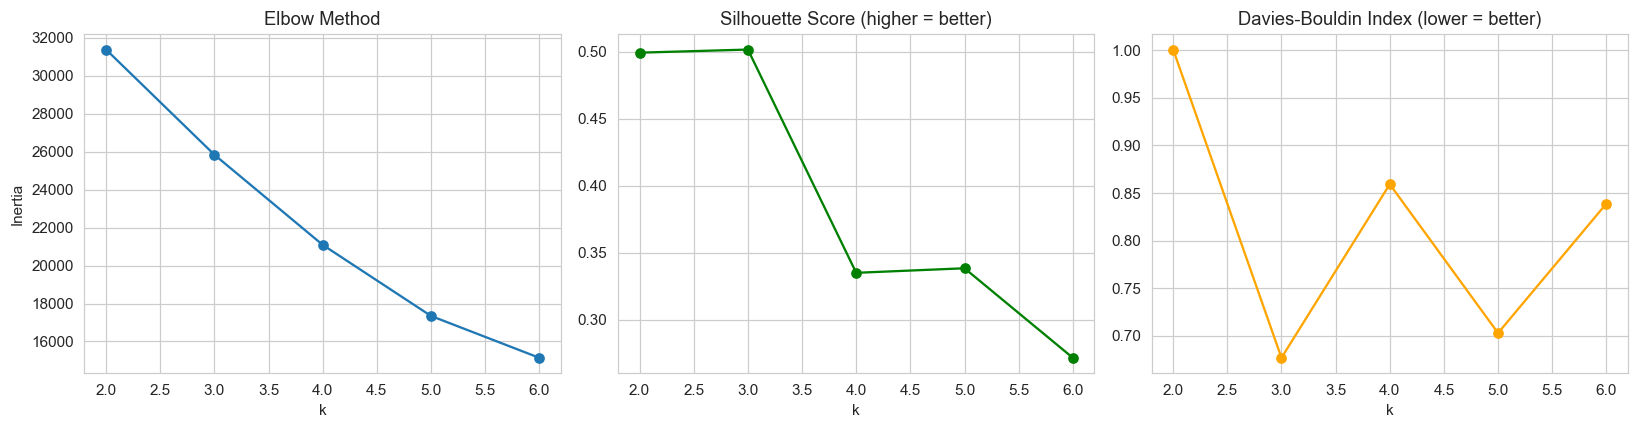

k=2: silhouette=0.499, davies_bouldin=1.001
k=3: silhouette=0.501, davies_bouldin=0.677
k=4: silhouette=0.335, davies_bouldin=0.859
k=5: silhouette=0.338, davies_bouldin=0.703
k=6: silhouette=0.272, davies_bouldin=0.839


In [11]:
k_range = range(2, 7)
inertias, silhouettes, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled, km.labels_))
    db_scores.append(davies_bouldin_score(scaled, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette Score (higher = better)")
axes[1].set_xlabel("k")

axes[2].plot(list(k_range), db_scores, marker="o", color="orange")
axes[2].set_title("Davies-Bouldin Index (lower = better)")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()

for k, s, d in zip(k_range, silhouettes, db_scores):
    print(f"k={k}: silhouette={s:.3f}, davies_bouldin={d:.3f}")


Pick the `k` that balances a low elbow inertia with a high silhouette score — for this dataset
that is usually **k = 3 or 4**. Set `BEST_K` below to whichever value your own printed scores
support (don't just copy a number — justify it from your own output in the report).

In [12]:
BEST_K = 4  # <-- set this based on the silhouette/elbow output above

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10).fit(scaled)
household_features["cluster_kmeans"] = kmeans.labels_

hier = AgglomerativeClustering(n_clusters=BEST_K).fit(scaled)
household_features["cluster_hier"] = hier.labels_

# DBSCAN needs no fixed k; eps/min_samples control how "tight" a neighbourhood must be
# to count as a cluster. Points labelled -1 are noise/outlier households.
dbscan = DBSCAN(eps=1.2, min_samples=15).fit(scaled)
household_features["cluster_dbscan"] = dbscan.labels_

print("K-Means cluster sizes:")
print(household_features["cluster_kmeans"].value_counts().sort_index())
print()
print("DBSCAN cluster sizes (-1 = noise/outlier households):")
print(household_features["cluster_dbscan"].value_counts().sort_index())


K-Means cluster sizes:
cluster_kmeans
0    3449
1    1823
2       1
3     257
Name: count, dtype: int64

DBSCAN cluster sizes (-1 = noise/outlier households):
cluster_dbscan
-1     298
 0    5232
Name: count, dtype: int64


### Dendrogram (Hierarchical clustering)

A dendrogram shows *how* clusters merge as you loosen the similarity threshold, and is a common
figure to include for the hierarchical-clustering comparison. We plot it on a random sample of 200
households (plotting all ~5,500 would be unreadable).

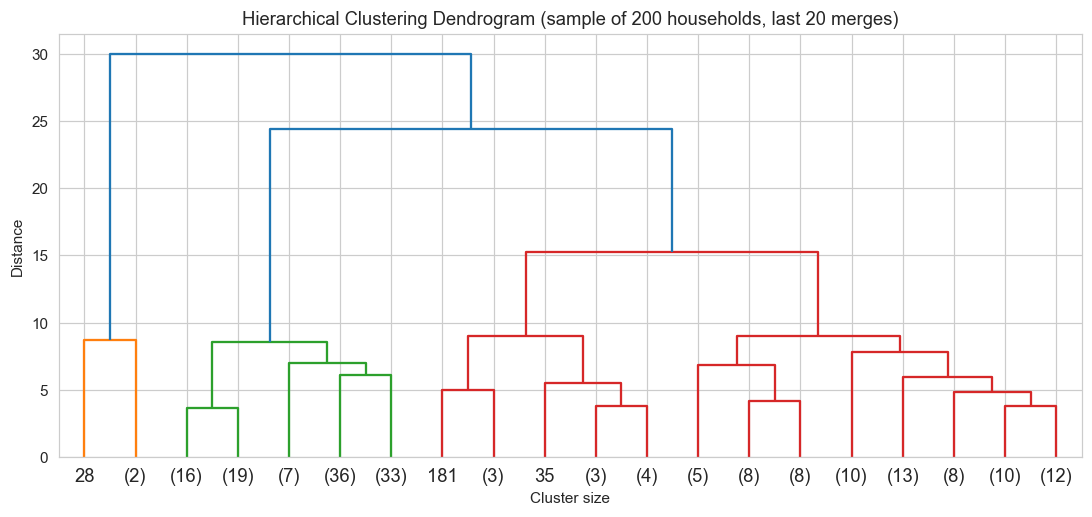

In [13]:
sample_idx = np.random.RandomState(42).choice(scaled.shape[0], size=200, replace=False)
linked = linkage(scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram (sample of 200 households, last 20 merges)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()


## Step 10 — Visualize and Profile the Clusters

Three views of the same result:

1. **PCA scatter plot** — the 2D projection colored by K-Means cluster, so you can see the
   separation visually.
2. **Cluster profile table** — the average of every raw feature per cluster, so you can *name*
   each cluster (e.g. "Cluster 0: low, steady usage").
3. **Acorn cross-tab** — a sanity check on whether the data-driven clusters relate to the known
   demographic groupings, without having used those labels to build the clusters.

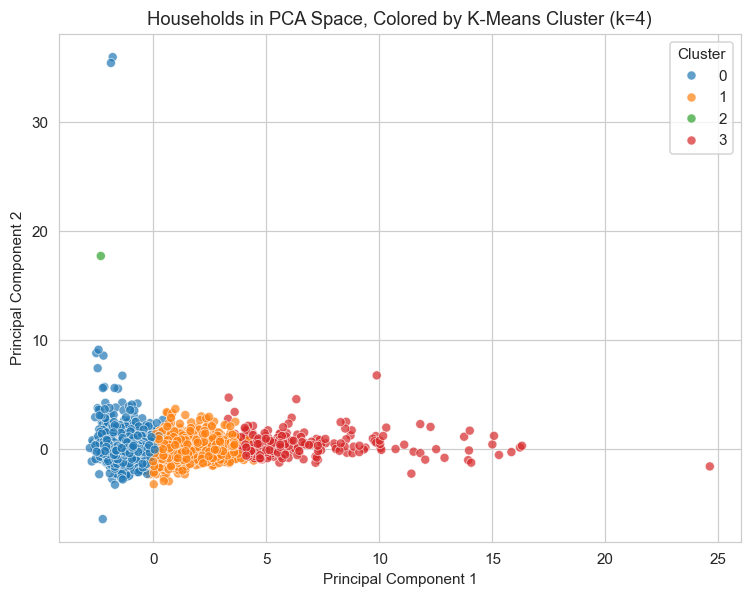

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=household_features, x="pca_1", y="pca_2",
    hue="cluster_kmeans", palette="tab10", s=35, alpha=0.7
)
plt.title(f"Households in PCA Space, Colored by K-Means Cluster (k={BEST_K})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


In [15]:
cluster_profile = household_features.groupby("cluster_kmeans")[feature_cols].mean().round(3)
print("Average feature values per cluster:")
cluster_profile


Average feature values per cluster:


,avg_daily_mean,avg_daily_std,avg_daily_max,avg_daily_min,total_consumption,variability_ratio,weekend_to_weekday_ratio,winter_to_summer_ratio
cluster_kmeans,,,,,,,,
0,0.129,0.044,0.558,0.034,3868.234,0.381,1.053,1.908
1,0.304,0.114,1.201,0.082,9199.804,0.379,1.067,1.664
2,0.044,0.077,0.316,0.008,1471.471,1.735,1.097,169772.150
3,0.689,0.325,1.968,0.248,20882.517,0.494,0.992,2.970


In [16]:
acorn_crosstab = pd.crosstab(household_features["cluster_kmeans"], household_features["Acorn_grouped"])
print("Cluster vs. Acorn demographic group (for validation only — not used to build the clusters):")
acorn_crosstab


Cluster vs. Acorn demographic group (for validation only — not used to build the clusters):


Acorn_grouped,ACORN-,ACORN-U,Adversity,Affluent,Comfortable
cluster_kmeans,,,,,
0,1,27,1288,1224,909
1,1,13,484,773,552
2,0,0,1,0,0
3,0,9,26,184,38


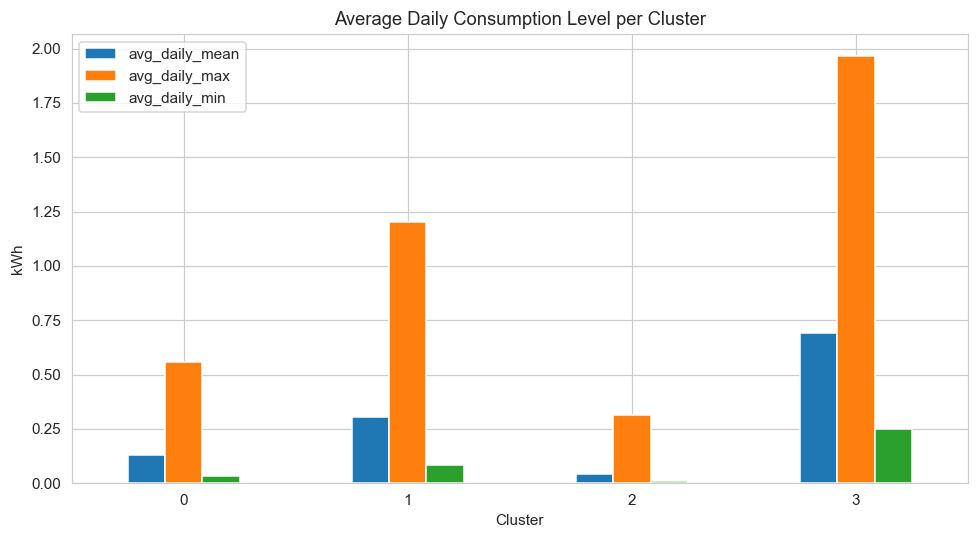

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
cluster_profile[["avg_daily_mean", "avg_daily_max", "avg_daily_min"]].plot(kind="bar", ax=ax)
ax.set_title("Average Daily Consumption Level per Cluster")
ax.set_ylabel("kWh")
ax.set_xlabel("Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 11 — Peak / Off-Peak Usage Analysis

**With the data currently loaded** (`daily_dataset.csv` has no hour-of-day column), the closest we
can get to "peak vs off-peak" is at the *day-type* level: which season and which weekday/weekend
combination is highest for each cluster. That's what the first cell below does.

**If you add `hhblock_dataset.csv`** (48 half-hourly columns `hh_0`...`hh_47` per household per
day), the second cell gives you genuine hour-of-day peak/off-peak detection — this is the version
your assignment is really asking for, so add that file if you can.

In [18]:
# Day-type level peak analysis (works with what you have now)
daily_with_cluster = daily_df.merge(
    household_features[["LCLid", "cluster_kmeans"]], on="LCLid", how="inner"
)

peak_summary = daily_with_cluster.groupby(["cluster_kmeans", "season", "is_weekend"])["energy_mean"].mean()
peak_summary = peak_summary.reset_index().sort_values(["cluster_kmeans", "energy_mean"], ascending=[True, False])

print("Highest and lowest average day-type per cluster:")
for c in sorted(daily_with_cluster["cluster_kmeans"].unique()):
    sub = peak_summary[peak_summary["cluster_kmeans"] == c]
    top = sub.iloc[0]
    low = sub.iloc[-1]
    print(f"Cluster {c}: PEAK -> {top['season']} / {'weekend' if top['is_weekend'] else 'weekday'} "
          f"({top['energy_mean']:.3f} kWh avg)   "
          f"OFF-PEAK -> {low['season']} / {'weekend' if low['is_weekend'] else 'weekday'} "
          f"({low['energy_mean']:.3f} kWh avg)")


Highest and lowest average day-type per cluster:
Cluster 0: PEAK -> winter / weekend (0.149 kWh avg)   OFF-PEAK -> summer / weekday (0.112 kWh avg)
Cluster 1: PEAK -> winter / weekend (0.377 kWh avg)   OFF-PEAK -> summer / weekday (0.238 kWh avg)
Cluster 2: PEAK -> winter / weekend (0.107 kWh avg)   OFF-PEAK -> summer / weekend (0.000 kWh avg)
Cluster 3: PEAK -> winter / weekday (0.892 kWh avg)   OFF-PEAK -> summer / weekend (0.443 kWh avg)


Since you now have `hhblock_dataset` (a folder of block files named `block_0.csv` ...
`block_109.csv`, each with columns `LCLid`, `day`, `hh_0` ... `hh_47`), the cell below:

1. Finds every `block_*.csv` file in that folder.
2. Reads them **one at a time** (not all at once — combined they can be several GB, so loading
   everything into memory at once can crash a laptop) and immediately maps each household to its
   K-Means cluster from Step 8.
3. Accumulates a running sum and count per cluster per half-hour slot, so memory stays small no
   matter how many files there are.
4. Some half-hourly values in this dataset are stored as the text `"Null"` instead of blank —
   `pd.to_numeric(..., errors="coerce")` converts those to proper missing values so they do not
   silently become 0 or crash the aggregation.
5. Divides the accumulated sum by the accumulated count at the end to get the true average
   24-hour load curve per cluster, then plots it and reads off the real peak/off-peak half-hour.

**Set `HHBLOCK_DIR` below to your actual folder path** — you already have it:
`D:\archive (1)\hhblock_dataset\hhblock_dataset`

In [19]:
import glob

# <-- set this to your actual folder (use a raw string r"..." on Windows so backslashes work)
HHBLOCK_DIR = r"D:\archive (1)\hhblock_dataset\hhblock_dataset"

hh_cols = [f"hh_{i}" for i in range(48)]
hh_files = sorted(glob.glob(f"{HHBLOCK_DIR}/block_*.csv"))
print(f"Found {len(hh_files)} block files")

cluster_ids = sorted(household_features["cluster_kmeans"].unique())
cluster_map = household_features.set_index("LCLid")["cluster_kmeans"]

cluster_sum = pd.DataFrame(0.0, index=cluster_ids, columns=hh_cols)
cluster_count = pd.DataFrame(0.0, index=cluster_ids, columns=hh_cols)

for i, f in enumerate(hh_files, start=1):
    block = pd.read_csv(f)
    block = block[block["LCLid"].isin(cluster_map.index)].copy()
    if block.empty:
        continue
    block["cluster_kmeans"] = block["LCLid"].map(cluster_map)

    # "Null" strings -> proper NaN, so they do not get counted as real zero-usage readings
    block[hh_cols] = block[hh_cols].apply(pd.to_numeric, errors="coerce")

    grouped_sum = block.groupby("cluster_kmeans")[hh_cols].sum(min_count=1)
    grouped_count = block.groupby("cluster_kmeans")[hh_cols].count()

    cluster_sum = cluster_sum.add(grouped_sum, fill_value=0)
    cluster_count = cluster_count.add(grouped_count, fill_value=0)

    if i % 20 == 0 or i == len(hh_files):
        print(f"  processed {i}/{len(hh_files)} files")

cluster_load_curve = cluster_sum / cluster_count.replace(0, np.nan)
print()
print("Average 24-hour load curve per cluster (first few half-hours):")
cluster_load_curve.iloc[:, :6]

Found 112 block files
  processed 20/112 files
  processed 40/112 files
  processed 60/112 files
  processed 80/112 files
  processed 100/112 files
  processed 112/112 files

Average 24-hour load curve per cluster (first few half-hours):


,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5
0,0.099394,0.088219,0.079766,0.073812,0.069833,0.067288
1,0.259671,0.246592,0.217486,0.193932,0.177436,0.168226
2,0.016926,0.016641,0.015396,0.014519,0.015133,0.014916
3,0.669747,0.696839,0.645632,0.593954,0.547030,0.512912


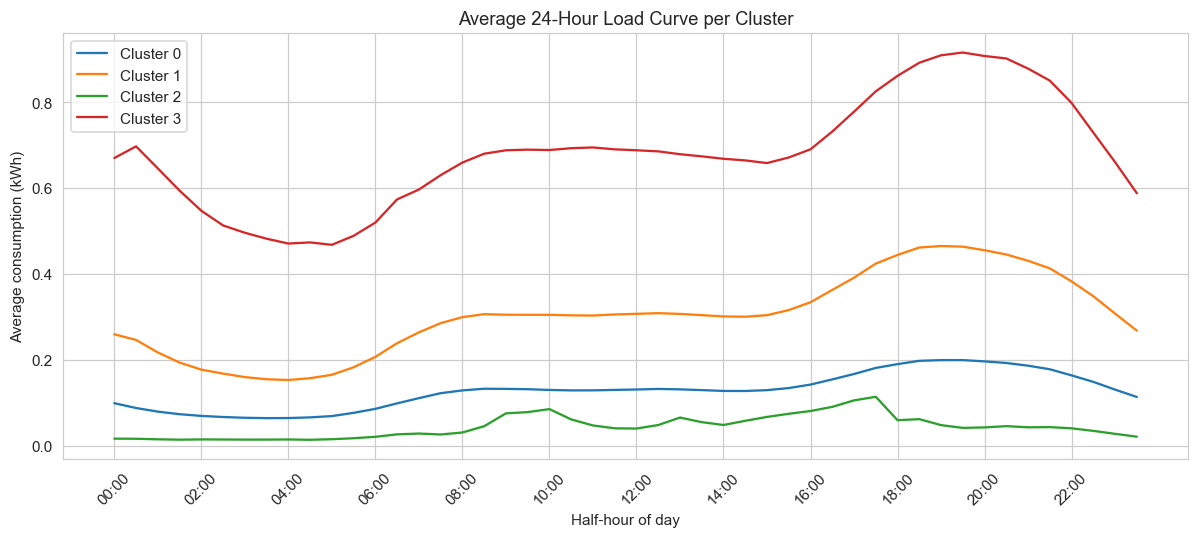

True hour-of-day peak / off-peak per cluster:
Cluster 0: PEAK at 19:30 (0.200 kWh avg)   OFF-PEAK at 03:30 (0.065 kWh avg)
Cluster 1: PEAK at 19:00 (0.465 kWh avg)   OFF-PEAK at 04:00 (0.153 kWh avg)
Cluster 2: PEAK at 17:30 (0.114 kWh avg)   OFF-PEAK at 04:30 (0.014 kWh avg)
Cluster 3: PEAK at 19:30 (0.915 kWh avg)   OFF-PEAK at 05:00 (0.468 kWh avg)


In [20]:
# Drop any cluster that has no data in the hh-block files at all (fully NaN row)
valid_clusters = cluster_load_curve.dropna(how="all").index

plt.figure(figsize=(11, 5))
for c in valid_clusters:
    plt.plot(range(48), cluster_load_curve.loc[c], label=f"Cluster {c}")
plt.xlabel("Half-hour of day")
plt.ylabel("Average consumption (kWh)")
plt.title("Average 24-Hour Load Curve per Cluster")
plt.xticks(range(0, 48, 4), [f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

def hh_to_time(col):
    n = int(col.split("_")[1])
    h, m = divmod(n * 30, 60)
    return f"{h:02d}:{m:02d}"

print("True hour-of-day peak / off-peak per cluster:")
skipped = [c for c in cluster_load_curve.index if c not in valid_clusters]
if skipped:
    print(f"(skipping cluster(s) {skipped} — no matching households found in the hh-block files)")
for c in valid_clusters:
    peak_hh = cluster_load_curve.loc[c].idxmax()
    offpeak_hh = cluster_load_curve.loc[c].idxmin()
    print(f"Cluster {c}: PEAK at {hh_to_time(peak_hh)} ({cluster_load_curve.loc[c, peak_hh]:.3f} kWh avg)   "
          f"OFF-PEAK at {hh_to_time(offpeak_hh)} ({cluster_load_curve.loc[c, offpeak_hh]:.3f} kWh avg)")

## Step 12 — Energy-Saving Recommendation Engine

A simple rule-based function: given a cluster's profile (its average level and its
winter/weekend behaviour), return a plain-language recommendation. This is deliberately not ML —
it's the interpretation layer that turns "Cluster 2 has a high winter-to-summer ratio" into
something a household or utility can act on.

In [21]:
def recommend_for_cluster(row):
    recs = []
    if row["winter_to_summer_ratio"] > 1.8:
        recs.append("Strong winter increase — likely electric heating. "
                     "Recommend a smart thermostat / heating schedule to avoid unnecessary overnight heating.")
    if row["weekend_to_weekday_ratio"] > 1.3:
        recs.append("Weekend-heavy usage — recommend running high-load appliances "
                     "(washing machine, dishwasher) during weekday off-peak hours instead.")
    elif row["weekend_to_weekday_ratio"] < 0.8:
        recs.append("Weekday-heavy usage, likely home unoccupied on weekends — "
                     "recommend checking for standby/phantom load during empty weekday daytime hours.")
    if row["variability_ratio"] > 1.0:
        recs.append("High day-to-day variability — recommend a consumption-tracking app "
                     "to help the household notice and flag unusually high days.")
    if row["avg_daily_mean"] < household_features["avg_daily_mean"].quantile(0.25):
        recs.append("Already a low, steady consumer — no major intervention needed; "
                     "candidate for a small loyalty/efficiency reward under a demand-response program.")
    if not recs:
        recs.append("Consumption pattern is close to average — general efficiency tips apply "
                     "(LED lighting, standby power audit).")
    return " ".join(recs)

cluster_summary = household_features.groupby("cluster_kmeans")[feature_cols].mean()
cluster_summary["recommendation"] = cluster_summary.apply(recommend_for_cluster, axis=1)

for c, row in cluster_summary.iterrows():
    print(f"--- Cluster {c} (n={sum(household_features['cluster_kmeans'] == c)}) ---")
    print(row["recommendation"])
    print()


--- Cluster 0 (n=3449) ---
Strong winter increase — likely electric heating. Recommend a smart thermostat / heating schedule to avoid unnecessary overnight heating.

--- Cluster 1 (n=1823) ---
Consumption pattern is close to average — general efficiency tips apply (LED lighting, standby power audit).

--- Cluster 2 (n=1) ---
Strong winter increase — likely electric heating. Recommend a smart thermostat / heating schedule to avoid unnecessary overnight heating. High day-to-day variability — recommend a consumption-tracking app to help the household notice and flag unusually high days. Already a low, steady consumer — no major intervention needed; candidate for a small loyalty/efficiency reward under a demand-response program.

--- Cluster 3 (n=257) ---
Strong winter increase — likely electric heating. Recommend a smart thermostat / heating schedule to avoid unnecessary overnight heating.



## Step 13 — Discussion: How This Supports Smart Energy Management

Use the cells above to write your discussion section. Points to cover, backed by your own output:

- **Targeted demand response**: which cluster(s) peak at the same time as the grid-wide peak, and
  so are the best targets for a demand-response alert.
- **Tariff design**: clusters with a high `weekend_to_weekday_ratio` or `winter_to_summer_ratio`
  could be offered a tariff shaped around their actual behaviour rather than a flat rate.
- **Infrastructure planning**: the relative *size* of each cluster (from `value_counts()` above)
  tells a utility roughly what share of a neighbourhood falls into each usage pattern, useful for
  transformer/feeder sizing.
- **Personalized guidance**: the recommendation engine in Step 12, generated per cluster rather
  than as one generic message to everyone.
- **Outlier handling**: households DBSCAN labelled `-1` are worth a manual look — possibly faulty
  meters or genuinely unusual consumption that a rigid K-Means cluster would have forced into the
  nearest group anyway.

Finally, save your key outputs (the cluster profile table, the PCA plot, the load-curve plot if you
added `hhblock_dataset.csv`) as figures for your report — you already have all of them above.

In [22]:
# Optional: save the final labelled household table for use in your report / dashboard
# (saved to the current working directory, not DATA_DIR, in case that folder is read-only)
household_features.to_csv("household_clusters_output.csv", index=False)
print("Saved household_clusters_output.csv with", household_features.shape[0], "households and their cluster labels.")


Saved household_clusters_output.csv with 5530 households and their cluster labels.
